In [1]:
## Packages
import os
import sys
import xarray as xr
xr.set_options(keep_attrs=True)
from dask.distributed import Client, LocalCluster, progress
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.lines as mlines
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
%matplotlib inline
import cartopy.crs as ccrs
import cartopy.feature as cfeat
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
import seaborn as sns
from functools import partial
import cftime
import time
import pandas as pd
from typing import Any
from metpy.calc import divergence, vorticity
import string
from dataclasses import dataclass

sys.path.append('/home/eastinev/ai')
## Personal
from file_utils import *
from metrics import *
from analysis_utils import *
from analysis import *
import plot_utils as utils
import paths as pth
import get_csv as gcsv

cluster = LocalCluster(n_workers=8, threads_per_worker=1)
client= Client(cluster)
print(client)

/home/eastinev/.conda/envs/climai/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Client: 'tcp://127.0.0.1:38161' processes=8 threads=8, memory=32.00 GiB>


In [27]:
GP_LAT, GP_LON = slice(35, 45), slice(-105, -85)
CUS_LAT, CUS_LON = slice(25, 51), slice(-110, -70)

PDF_KWARGS = {
    'binwidth': 0.1,  # this bin width (log10 space) used in Ma et al 2022; they also use from 10^-2 to 10^3
    'fill': False,
    'element': 'poly',
    'x': 'precip',
    'stat': 'density',
    'hue': 'models',
    'log_scale': True,
    'common_norm': False,
    'multiple': 'dodge'
}
CDF_KWARGS = PDF_KWARGS | {'cumulative': True}
NN_all_label = r'NN$_{\text{all}}$'
NN_lim_label = r'NN$_{\text{lim}}$'
PANELS = [a + b + c for a, b, c in zip(['('] * 26, string.ascii_lowercase, [') '] * 26)]

H3_TO_D = 8

mpl.rcParams.update({
    'pdf.fonttype': 42,  # type 42 pdf for embedded text (?)
    'font.size': 12,          # Global default text size
    'axes.titlesize': 14,     # Title size
    'axes.labelsize': 12,     # X and Y label size
    'xtick.labelsize': 10,    # X-tick label size
    'ytick.labelsize': 10,    # Y-tick label size
    'legend.fontsize': 10,    # Legend font size
    'figure.titlesize': 20    # Figure suptitle size
})
CBAR_FONTSIZE = 12
COL_SIZE = 11
ROW_SCALE = 3

In [28]:
## Helpers
def select_great_plains(data: xr.DataArray) -> xr.DataArray:
    return data.sel(lat=GP_LAT, lon=GP_LON)

def threshold(data: xr.DataArray, threshold_value: float, other: float = np.nan) -> xr.DataArray:
    return data.where(data >= threshold_value, other)

def make_daily(three_hourly_data: xr.DataArray) -> xr.DataArray:
    return three_hourly_data.resample(time='D').sum(dim='time').dropna('time', how='all')

def make_seasonal(daily_data: xr.DataArray) -> xr.DataArray:
    return daily_data.groupby('time.season').mean(dim='time', skipna=True)

def diurnal_mean(three_hourly_data: xr.DataArray, scale: int = H3_TO_D) -> xr.DataArray:
    return three_hourly_data.groupby('time.hour').mean('time', skipna=True) * scale

def empty_ds(data: xr.Dataset) -> xr.Dataset:
    ds = xr.full_like(data, np.nan)
    ds = ds.assign_attrs(label='', linestyle='')
    return ds

def show(fig: plt.Figure) -> plt.Figure:
    return fig

def wrap_0hr(ds: xr.Dataset, amnt: int = -4, append: bool = False) -> xr.Dataset:
    ds = ds.roll(hour=amnt, roll_coords=True)
    if not append:
        return ds
    else:
        wrap = ds.isel(hour=0)
        return xr.concat([ds, wrap], dim='hour').assign_coords({'hour': np.arange(0, 25, 3)})

def utc_to_lst(ds: xr.Dataset, time_coord: str = 'time', lon_coord: str = 'lon') -> xr.Dataset:
    """
    Calculates Mean Local Solar Time from UTC and longitude, and 
    adds it as a new 2D coordinate to the xarray Dataset.
    
    Parameters:
    ds (xr.Dataset): The input dataset containing time and longitude coordinates.
    time_coord (str): The name of the UTC time coordinate.
    lon_coord (str): The name of the longitude coordinate.
    
    Returns:
    xr.Dataset: The dataset with a new 'local_solar_time' coordinate.
    """
    
    # 1. Normalize longitude to [-180, 180] 
    # This ensures offsets are correct relative to the current UTC date
    lon_180 = (ds[lon_coord] + 180) % 360 - 180
    
    # 2. Calculate the time offset in seconds
    # Earth rotates 15 degrees per hour -> 1 degree = 4 mins = 240 seconds
    offset_seconds = np.round(lon_180 * 240).astype(int)
    
    # 3. Convert to numpy timedelta64
    offset_timedelta = offset_seconds.astype('timedelta64[s]')

    # adjust calendar from cftime noleap to np datetimes
    if type(ds[time_coord][0].data) != np.datetime64:
        ds[time_coord] = ds[time_coord].values.astype('datetime64[ns]')

    # 4. Broadcast the time and offset to create a 2D (time, lon) DataArray
    local_solar_time = ds[time_coord] + offset_timedelta
    
    # 5. Assign the new 2D coordinate back to the dataset
    return ds.assign_coords(local_solar_time=local_solar_time)

def bin_3hourly(ds: xr.Dataset, lat_mean: bool) -> xr.DataArray:
    hour_bins = np.arange(0, 25, 3)
    bin_labels = np.arange(0, 24, 3)
    out = []
    for lon in ds.lon.data:
        lon_data = ds.sel(lon=lon)
        if lat_mean: lon_data = lat_wtd_mean(lon_data, dim=['lat'])
        frac_hour = lon_data.local_solar_time.dt.hour + (lon_data.local_solar_time.dt.minute / 60.0)
        shift_hour = (frac_hour + 1.5) % 24
        diurnal = lon_data.groupby_bins(
            shift_hour,
            bins=hour_bins, 
            labels=bin_labels,
            right=False # Include left edge, exclude right edge
        ).mean(dim='time')
        out.append(diurnal)
    
    return xr.concat(out, dim='lon').rename({'group_bins': 'hour'}).transpose()

def lst_diurnal_mean(ds: xr.Dataset, lat_mean: bool = False) -> xr.DataArray:
    return bin_3hourly(utc_to_lst(ds), lat_mean) * H3_TO_D

In [29]:
## Plot helpers
@dataclass
class PanelConfig:
    index: int
    name: str
    nrow: int
    ncol: int
    projection: None | ccrs.CRS = None
    fontsize: int = 12

    @property
    def add_x(self):
        return self.index in list(range(self.nrow * self.ncol))[-self.ncol:]

    @property
    def add_y(self):
        return (self.index % self.ncol) == 0

    @property
    def title(self):
        return PANELS[self.index] + self.name

def region_plot(
    data: xr.Dataset,
    ax: plt.Axes,
    cmap_kwargs: dict,
    panel: PanelConfig,
) -> (plt.Axes, Any):

    lats, lons = data.lat.data, data.lon.data
    lat_ticks = np.arange(lats[0], lats[-1] + 1, 5).tolist()
    dlon = 10 if int(lons[0]) == -110 else 5
    lon_ticks = np.arange(lons[0], lons[-1], dlon).tolist()
    extent = (lons[0], lons[-1], lats[0], lats[-1])
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    plt_obj = ax.contourf(lons, lats, data, transform=ccrs.PlateCarree(), **cmap_kwargs)
    ax.add_feature(cfeat.STATES, linewidth=0.25)
    configure_panel(ax, panel, lon_ticks, lat_ticks)

    return ax, plt_obj

def region_quiver_plot(winds: xr.Dataset, ax: plt.Axes) -> (plt.Axes, Any):
    lats, lons = winds.lat.data, winds.lon.data
    extent = (lons[0], lons[-1], lats[0], lats[-1])
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    plt_obj = ax.quiver(lons, lats, winds.U.data, winds.V.data, transform=ccrs.PlateCarree())
    ax.add_feature(cfeat.STATES, linewidth=0.5)
    return ax, plt_obj

def configure_panel(ax: plt.Axes, panel: PanelConfig, lon_ticks: list, lat_ticks: list) -> None:
    ax.set_title(panel.title, loc='left', fontsize=panel.fontsize)
    if panel.add_x: set_xticks(ax, lon_ticks, panel.projection)
    if panel.add_y: set_yticks(ax, lat_ticks, panel.projection)
    add_grid(ax, lat_ticks, lon_ticks)
    
def add_grid(ax, lat_ticks, lon_ticks):
    gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.xlocator = ticker.FixedLocator(lon_ticks)
    gl.ylocator= ticker.FixedLocator(lat_ticks)

def set_xticks(ax, lon_ticks, map_proj):
    if map_proj is None:
        ax.set_xticks(lon_ticks)
    else:
        ax.set_xticks(lon_ticks, crs=map_proj)
    lon_formatter = LongitudeFormatter(degree_symbol='')
    ax.xaxis.set_major_formatter(lon_formatter)

def set_yticks(ax, lat_ticks, map_proj):
    ax.set_yticks(lat_ticks, crs=map_proj)
    lat_formatter = LatitudeFormatter(degree_symbol='')
    ax.yaxis.set_major_formatter(lat_formatter)

# Test Data Results

In [79]:
## spatial permutation importance
def plot_importance(metric: str = 'ets'):
    nrow, ncol = 1, 2
    fig, axs = plt.subplots(1, 2, sharey=True, gridspec_kw={'wspace': -0.55, 'hspace': 0.}, figsize=(COL_SIZE, nrow * ROW_SCALE))
    models = ['test2_JJA_F00h', 'noQW_JJA_F00h']
    _ids = [NN_all_label, NN_lim_label]
    for i, (model_name, _id, ax) in enumerate(zip(models, _ids, axs.flatten())):
        stats = []
        for v in ['T', 'H', 'OMEGA', 'U', 'V', 'QV']:
            try:
                df = pd.read_csv(f'./models/{model_name}/{v}_shuffle.csv', index_col=0)
            except FileNotFoundError as e:
                continue
            for index, data in df.iterrows():
                stats.append({
                    'label': index,
                    'mean': data[f'{metric}_imp_mean'],
                    'med': data[f'{metric}_imp_med'],
                    'q1': data[f'{metric}_imp_25p'],
                    'q3': data[f'{metric}_imp_75p'],
                    'whislo': data[f'{metric}_imp_25p'],
                    'whishi': data[f'{metric}_imp_75p']
                })

        stats = sorted(stats, key=lambda x: x['med'], reverse=True)
        stats = stats[:10]
        ax.bxp(stats, showfliers=False, showmeans=True, meanline=True)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
        ax.axhline(y=0, color='gray', linewidth=1, linestyle='--')
        ax.set_title(PANELS[i] + _id, loc='left', fontsize=10)
        ax.set(box_aspect=1)
        if i == 0: ax.set_ylabel(f'{metric.upper()} Importance', fontsize=10)
    return fig

fig = plot_importance(metric='ets')
# show(fig)
plt.savefig('./feat_importance.pdf', bbox_inches='tight', pad_inches=0.02, format='pdf')

In [31]:
## Full (Z, V, T, w, q) model results
full_model = 'test2_JJA_F00h'
full_test_mcs = xr.open_dataset(f'./models/{full_model}/MODEL_PRED.nc')

## Large-scale only (Z, V, T) model results
lsf_model = 'noQW_JJA_F00h'
lsf_test_mcs = xr.open_dataset(f'./models/{lsf_model}/MODEL_PRED.nc')

## MSWEP precipitation for model test set; these should be the same for both models AFAIK...
mswep_test_mcs = xr.open_dataset(f'./models/{full_model}/MSWEP.nc')

### Compile test set results
test_three_hourly = [
    full_test_mcs,
    lsf_test_mcs,
    mswep_test_mcs,
]

# TODO(ereastin): better names..?
TEST_LABELS = [
    NN_all_label,
    NN_lim_label,
    'MSWEPv2',
]

TEST_LINESTYLES = [
    'b-',
    'g-',
    'k-',
]

test_three_hourly = [da.assign_attrs(label=l, linestyle=ls) for da, l, ls in zip(test_three_hourly, TEST_LABELS, TEST_LINESTYLES)]
test_three_hourly = [threshold(da, 0.0, 0.0) for da in test_three_hourly] # this because DL models will predict negative values

In [32]:
## daily data::
# this doesn't quite make sense but at least consistent comparison; some 'days' may not be complete bc of MCS 3hourly filtering
# but can probably just consider this as an MCS day
test_daily = [make_daily(da) for da in test_three_hourly]

In [33]:
## seasonal data
test_seasonal = [make_seasonal(da) for da in test_daily]

In [34]:
# peak_time = select_great_plains_wide(test_three_hourly_filtered[-1]).sum(['lat', 'lon']).idxmax('time')['precip'].data
# # peak_time -= np.timedelta64(3, 'h')
# print(peak_time)

# fields_path = os.path.join(pth.SCRATCH, 'cus', 'LSF*.nc')
# merra_fields = open_mf(fields_path, lat=CUS_LAT, lon=CUS_LON).sel(time=str(peak_time)).squeeze(drop=True)
# merra_fields['lev'] = merra_fields['lev'] * 100
# tcwv = merra_fields['QV'].integrate('lev') / -9.8
# tcs = calc_qsat(merra_fields['T'], merra_fields['lev']).integrate('lev') / -9.8
# crh = tcwv / tcs
# omega = merra_fields['OMEGA'].sel(lev=55000)
# ## actually what is a good level for this..? if convection initiates above PBL then..? 850?
# div = divergence(merra_fields['U'].sel(lev=92500), merra_fields['V'].sel(lev=92500))
# vor = vorticity(merra_fields['U'].sel(lev=slice(60000, 50000)).mean('lev'), merra_fields['V'].sel(lev=slice(60000, 50000)).mean('lev'))
# winds = merra_fields[['U', 'V']].sel(lev=92500)

In [51]:
## case-specific precip
def plot_precip(precip, time_slice, fig=None, axs=None):
    clrs = ['#FFFFFF','#BEFFFF','#79C8FF','#3E62FF','#2F2DDE','#79DA62','#58D248','#3BBF3D','#28A83A','#F8FB64', '#FFD666','#FFA255','#FF6039','#F61F1F','#CD3B3B','#AC3333','#CD1599','#C725E0']
    cmap = mpl.colors.LinearSegmentedColormap.from_list('p_cmap', clrs, 18)
    cmap.set_bad(color='white')
    cmap.set_under(color='white')
    levels = np.linspace(0, 17, 18)
    map_proj = ccrs.PlateCarree()
    cmap_kwargs = {'cmap': cmap, 'levels': levels, 'extend': 'max'}
    nrow, ncol = 1, 3
    if fig is None and axs is None:
        fig, axs = plt.subplots(
            nrow,
            ncol,
            subplot_kw={'projection': map_proj},
            gridspec_kw={'wspace': 0.1, 'hspace': 0},
            figsize=(COL_SIZE, nrow * ROW_SCALE)
        )

    for i, (ax, da) in enumerate(zip(axs, precip)):
        panel = PanelConfig(i, da.attrs['label'], nrow, ncol, projection=map_proj)
        ax, _ = region_plot(da['precip'], ax, cmap_kwargs, panel)
        rmse = np.sqrt(np.mean((da['precip'] - precip[-1]['precip']) ** 2))
        pc = pcc(da['precip'], precip[-1]['precip'])
        if i < 2:
            stats = f'{pc:.2f}/{rmse:.2f}'
            ax.set_title(stats, loc='right')

        if i == 0:
            ax.plot([GP_LON.start, GP_LON.stop], [GP_LAT.start, GP_LAT.start], 'k--')
            ax.plot([GP_LON.stop, GP_LON.stop], [GP_LAT.start, GP_LAT.stop], 'k--')
            ax.plot([GP_LON.start, GP_LON.start], [GP_LAT.start, GP_LAT.stop], 'k--')
            ax.plot([GP_LON.start, GP_LON.stop], [GP_LAT.stop, GP_LAT.stop], 'k--')
            # ax.set(ylabel='Latitude')
        if i == 1:
            ax.set(xlabel='Longitude')

    cbar = fig.colorbar(
        cm.ScalarMappable(norm=mpl.colors.BoundaryNorm(levels, cmap.N, extend='max'), cmap=cmap),
        ax=axs,
        fraction=0.025,
        pad=0.025,
        shrink=0.8,
        orientation='vertical'
    )
    cbar.set_label('mm', fontsize=CBAR_FONTSIZE)
    return fig

peak_time = '2010-06-26T03'
precip = [da.sel(time=peak_time).squeeze(drop=True) for da in test_three_hourly]
fig = plot_precip(precip, str(peak_time))
# show(fig)
plt.savefig(f'./test_{peak_time}.pdf', bbox_inches='tight', format='pdf', pad_inches=0.02)

In [36]:
def plot_precip_fields(precip, fields, time_slice):
    fig, axs = plt.subplots(1, len(precip), subplot_kw={'projection': map_proj}, figsize=(16, 12))
    fig, axs = plot_precip(precip, time_slice, fig, axs)
    cmap2 = cm.YlGnBu
    lev2 = np.linspace(0, 60, 13)
    cmap2_kw = {'cmap': cmap2, 'levels': lev2, 'extend': 'max'}
    ax, ob = region_plot(fields[0], axs[1, 0], cmap2_kw)
    ax.set(title='Total Column Water Vapor')
    fig.subplots_adjust(bottom=0.3)
    cbar2_ax = fig.add_axes([0.14, 0.28, 0.2, 0.02])
    cbar2 = fig.colorbar(
        cm.ScalarMappable(norm=mpl.colors.BoundaryNorm(lev2, cmap2.N, extend='max'), cmap=cmap2),
        cax=cbar2_ax,
        orientation='horizontal'
    )
    cbar2.set_label(r'kg m$^{-2}$', fontsize=10)
    cmap3 = cm.bwr
    lev3 = np.linspace(-1, 1, 11)
    cmap3_kw = {'cmap': cmap3, 'levels': lev3, 'extend': 'both'}
    ax, ob = region_plot(fields[1], axs[1, 1], cmap3_kw)
    ax.set(title=r'550 hPa $\omega$')
    cbar3_ax = fig.add_axes([0.41, 0.28, 0.2, 0.02])
    cbar3 = fig.colorbar(
        cm.ScalarMappable(norm=mpl.colors.BoundaryNorm(lev3, cmap3.N, extend='both'), cmap=cmap3),
        cax=cbar3_ax,
        orientation='horizontal'
    )
    cbar3.set_label(r'Pa s$^{-1}$', fontsize=10)
    cmap4 = cm.YlGnBu
    lev4 = np.linspace(0, 1, 21)
    ext4 = 'neither'
    cmap4_kw = {'cmap': cmap4, 'levels': lev4, 'extend': ext4}
    ax, ob = region_plot(fields[2], axs[1, 2], cmap4_kw)
    ax.set(title='925 hPa divergence')
    cbar4_ax = fig.add_axes([0.685, 0.28, 0.2, 0.02])
    cbar4 = fig.colorbar(
        cm.ScalarMappable(norm=mpl.colors.BoundaryNorm(lev4, cmap4.N, extend=ext4), cmap=cmap4),
        cax=cbar4_ax,
        orientation='horizontal'
    )
    cbar4.set_label(r'x10$^5$ s$^{-1}$', fontsize=10)
    ax, ob = region_quiver_plot(fields[3], axs[1, 2])
    fig.text(0.52, 0.9, time_slice.split(':')[0] + 'Z', ha='center', fontsize=14)
    return fig

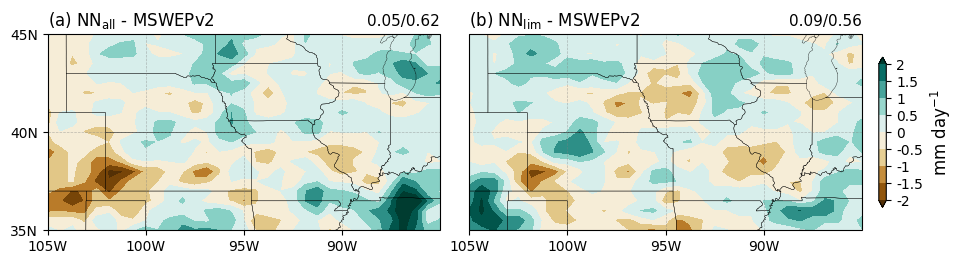

In [72]:
## spatial seasonal/daily mean results..?
def spatial_bias_plot(datas: list[xr.DataArray], nrow: int = 1, ncol: int = 3) -> plt.Figure:
    map_proj = ccrs.PlateCarree()
    bounds = np.linspace(-2, 2, 9)
    cmap_kwargs = {'cmap': 'BrBG', 'levels': bounds, 'extend': 'both'}
    fig, axs = plt.subplots(
        nrow,
        ncol,
        sharey=True,
        subplot_kw={'projection': map_proj},
        gridspec_kw={'wspace': 0.075, 'hspace': 0},
        figsize=(COL_SIZE, nrow * ROW_SCALE)
    )

    for i, (ax, data) in enumerate(zip(axs.flat, datas)):
        dat = data.sel(season='JJA')['precip']
        panel = PanelConfig(i, data.attrs['label'].replace(' CTRL', '') + ' - MSWEPv2', nrow, ncol, map_proj)
        ax, ob = region_plot(dat, ax, cmap_kwargs, panel)
        diff, rmse = lat_wtd_mean(dat, dim=['lat', 'lon']).data, np.sqrt(lat_wtd_mean(dat ** 2, dim=['lat', 'lon'])).data
        ax.set_title(f'{diff:.2f}/{rmse:.2f}', loc='right', fontsize=11)

    # fig.subplots_adjust(right=0.9)
    # cbar_ax = fig.add_axes([0.93, 0.255, 0.01, 0.48])
    cmap = cm.BrBG
    cbar = fig.colorbar(
        cm.ScalarMappable(norm=mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both'), cmap=cmap),
        ax=axs, #cax=cbar_ax,
        fraction=0.025,
        pad=0.02,
        shrink=0.65,
        orientation='vertical'
    )
    cbar.set_label(r'mm day$^{-1}$', fontsize=CBAR_FONTSIZE)
    cbar.ax.set_yticklabels([f'{x:g}' for x in np.arange(-2, 2.1, 0.5)])
    return fig

diffs = [
    test_seasonal[0] - test_seasonal[2],
    test_seasonal[1] - test_seasonal[2],
]
gp_diffs = [select_great_plains(da) for da in diffs]
# print(lat_wtd_mean(test_seasonal[2], ['lat', 'lon']))
fig = spatial_bias_plot(gp_diffs, nrow=1, ncol=2)
show(fig)
# plt.savefig('./test_bias.pdf', bbox_inches='tight', pad_inches=0.02, format='pdf')

In [20]:
def spatial_phase(three_hourly, seasonal, nrow=1, ncol=3, figsize=None):
    as_lst_dcp = [lst_diurnal_mean(select_great_plains(ds), lat_mean=False) for ds in three_hourly]
    out = []
    for hrly, smn in zip(as_lst_dcp, seasonal):
        fft_out = xr.apply_ufunc(
            np.fft.fft,
            hrly, # - hrly.mean('hour', skipna=True),
            input_core_dims=[['hour']],
            output_core_dims=[['frequency']],
            exclude_dims=set(('hour',)),
            dask='parallelized',
            vectorize=True,
            keep_attrs=True
        )
        n_time = hrly.sizes['hour']
        freqs = np.fft.fftfreq(n_time, d=1/8)
        fft_out = fft_out.assign_coords(frequency=freqs)
        diurnal = fft_out.sel(frequency=1.)
        semi_diurnal = fft_out.sel(frequency=2.)
        d_amp, d_phs = np.abs(diurnal), xr.ufuncs.angle(diurnal)  # NOTE(ereastin): this the right 'amplitude'?
        sd_amp, sd_phs = np.abs(semi_diurnal), xr.ufuncs.angle(semi_diurnal)
        phase_out = xr.where((d_amp / smn >= 0.25) | (smn >= 0.75), d_phs, np.nan, keep_attrs=True)
        out.append(phase_out)

    map_proj = ccrs.PlateCarree()
    fig, axs = plt.subplots(nrow, ncol, subplot_kw={'projection': map_proj}, figsize=figsize)
    bounds = np.linspace(-np.pi, np.pi, 25)
    cmap = cm.hsv
    cmap_kwargs = {'cmap': cmap, 'levels': bounds, 'extend': 'neither'}
    for i, (ax, data) in enumerate(zip(axs.flat, out)):
        panel = PanelConfig(i, data.attrs['label'], nrow, ncol, projection=map_proj)
        ax, ob = region_plot(data.sel(season='JJA')['precip'], ax, cmap_kwargs, panel)

    cbar_ticks = [str(a).zfill(2) for a in np.arange(12, -1, -1).tolist() + np.arange(23, 11, -1).tolist()]
    fig.subplots_adjust(right=0.9)
    cbar_ax = fig.add_axes([0.93, 0.25, 0.015, 0.5])
    cbar = fig.colorbar(
        cm.ScalarMappable(norm=mpl.colors.BoundaryNorm(bounds, cmap.N, extend='neither'), cmap=cmap),
        cax=cbar_ax,
        orientation='vertical',
        label='Diurnal Phase (LST Hour)'
    )
    cbar.ax.set_yticklabels(cbar_ticks)

    return fig

fig = spatial_phase(
    [select_great_plains(da) for da in test_three_hourly],
    [select_great_plains(da) for da in test_seasonal],
    figsize=(12, 4)
)
# plt.savefig('./test_phase.png', bbox_inches='tight', dpi=300, pad_inches=0.02)
# show(fig)

In [16]:
## thinking more like the timing of high-intensity events.?
## so lets look for 97.5, 99.9 99.99 percentiles of the filtered 3-hourly data.?
def line_diurnal(data: list[xr.Dataset]) -> plt.Figure:
    fig, ax = plt.subplots(layout='constrained')
    for da in data:
        da['precip'].plot.line(da.attrs['linestyle'], ax=ax, label=da.attrs['label'])
    ax.legend()
    ax.set(
        xlabel='UTC Hour',
        ylabel='Mean Precipitation (mm/day)'
    )
    return fig

def plot_extreme_dcp_line(datas: list[xr.Dataset], percentile: float) -> plt.Figure:
    gp = [select_great_plains(da) for da in datas]
    ext = [da.where(da >= np.nanpercentile(da.to_dataarray().data.flat, percentile)) for da in gp]
    mean_ext_dcp = [lat_wtd_mean(diurnal_mean(da, scale=1), dim=['lat', 'lon']) for da in ext]
    return line_diurnal(mean_ext_dcp)

def spatial_plot(datas: list[xr.Dataset]) -> plt.Figure:
    lons, lats = datas[0].lon.data, datas[0].lat.data
    map_proj = ccrs.AlbersEqualArea(
        central_longitude=(lons[0] - lons[-1]) // 2 + lons[-1],
        central_latitude=(lats[0] - lats[-1]) // 2 + lats[-1]
    )
    bounds = np.linspace(0, 500, 11)
    cmap = cm.YlGnBu
    extend = 'max'
    cmap_kwargs = {'cmap': cmap, 'levels': bounds, 'extend': extend}
    fig, axs = plt.subplots(1, len(datas), subplot_kw={'projection': map_proj}, figsize=(12, 6))
    
    for ax, data in zip(axs.flat, datas):
        dat = data['precip']
        ax, ob = region_plot(dat, ax, cmap_kwargs)
        ax.set(title=data.attrs['label'] )

    fig.subplots_adjust(right=0.9)
    cbar_ax = fig.add_axes([0.93, 0.23, 0.02, 0.53])
    cbar = fig.colorbar(
        cm.ScalarMappable(norm=mpl.colors.BoundaryNorm(bounds, cmap.N, extend=extend), cmap=cmap),
        cax=cbar_ax,
        orientation='vertical'
    )
    cbar.set_label(r'mm yr$^{-1}$', fontsize=10)
    return fig

def plot_extreme_spatial(datas, percentile):
    # annual mean of total precip from 95+ percentile rain.? percentile value determined from all days in dataset.?
    gp = [select_great_plains(da) for da in datas]
    ext = [da.where(da >= np.nanpercentile(da.to_dataarray().data.flat, percentile)) for da in gp]  # masked da for rain greater than 95%
    ann = [da.groupby('time.year').sum('time', skipna=True).mean('year') for da in ext]
    return spatial_plot(ann)

# plot_extreme_spatial(test_three_hourly_filtered, 95.)
# plot_extreme_dcp_line(test_three_hourly_filtered, 95.)

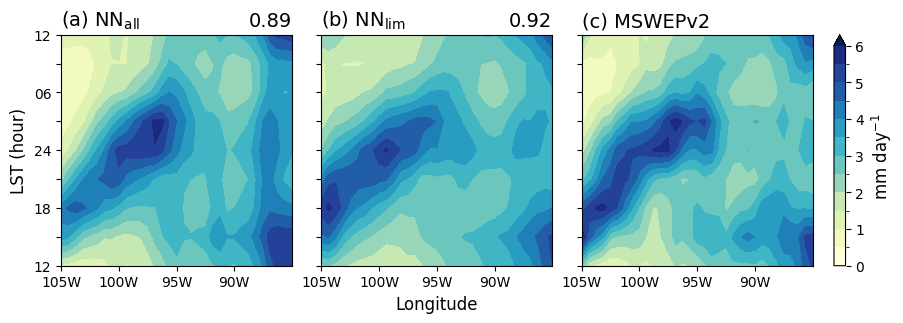

In [69]:
test_hovmoller = [
    wrap_0hr(lst_diurnal_mean(select_great_plains(ds), lat_mean=True), append=True) for ds in test_three_hourly
]

def hovmoller(data: list[xr.Dataset], nrow, ncol) -> plt.Figure:
    fig, axs = plt.subplots(nrow, ncol, sharey=True, gridspec_kw={'wspace': -0.1, 'hspace': 0}, figsize=(COL_SIZE, nrow * ROW_SCALE))

    yticks = data[-1].hour.data
    ytick_labels = [str(t).zfill(2) for t in np.arange(12, 25, 3).tolist() + np.arange(3, 13, 3).tolist()]
    ytick_labels = [t if (i % 2 == 0) else '' for i, t in enumerate(ytick_labels)]
    vmin, vmax = 0, 6
    levels = 13
    bounds = np.linspace(vmin, vmax, levels)
    cmap = cm.YlGnBu
    for i, (da, ax) in enumerate(zip(data, axs.flatten())):
        axobj = da['precip'].plot.contourf(
            ax=ax,
            vmin=vmin,
            vmax=vmax,
            levels=levels,
            extend='max',
            cmap=cmap,
            add_colorbar=False
        )
        ax.set(
            box_aspect=1,
            yticks=yticks,
            yticklabels=ytick_labels,
            ylabel='',
            xlabel=''
        )
        set_xticks(ax, np.arange(da.lon.data[0], da.lon.data[-1], 5).tolist(), None)
        ax.set_title(PANELS[i] + da.attrs['label'], loc='left')
        # ax.tick_params(axis='both', which='major', labelsize=14)
        if i < 2: # add some pattern correlation
            pc = pcc(da['precip'], data[-1]['precip'])
            ax.set_title(f'{pc:.2f}', loc='right')
        if i == 0:
            ax.set(ylabel='LST (hour)')
        if i == 1:
            ax.set(xlabel='Longitude')

    cbar = fig.colorbar(
        cm.ScalarMappable(norm=mpl.colors.BoundaryNorm(bounds, cmap.N, extend='max'), cmap=cmap),
        ax=axs, # cax=cbar_ax,
        fraction=0.025,
        pad=0.025,
        orientation='vertical'
    )
    cbar.set_label(r'mm day$^{-1}$', fontsize=CBAR_FONTSIZE)
    return fig

fig = hovmoller(test_hovmoller, 1, 3)
show(fig)
# plt.savefig('./test_hovmoller.pdf', bbox_inches='tight', pad_inches=0.02, format='pdf')

In [ ]:
## cdf
def plot_cdf(data: list[xr.DataArray], ax: plt.Axes) -> plt.Axes:
    is_daily = (data[0].time[1] - data[0].time[0]).astype('timedelta64[D]') == np.timedelta64(1, 'D')
    if is_daily:
        ylim = (0, 4)
        yticks = np.arange(5)
    else:
        ylim = (0, 1)
        yticks = np.arange(2)
    
    flat_data = [da.to_dataarray().data.flatten() for da in data]
    labels = [da.attrs['label'] for da in data]
    colors = [da.attrs['linestyle'][0] for da in data]
    ls = [da.attrs['linestyle'][1:] for da in data][0]
    mask = [~np.isnan(arr) for arr in flat_data]
    masked_data = [arr[m] for arr, m in zip(flat_data, mask)]
    df_dict = {}
    for arr, lab in zip(masked_data, labels):
        # print(lab, len(arr))
        df_dict[lab] = arr
    df = pd.DataFrame({k: pd.Series(v) for k, v in df_dict.items()})
    df = df.melt(var_name='models', value_name='precip')
    ax = sns.histplot(data=df, ax=ax, palette=colors, linestyle=ls, legend=False, **CDF_KWARGS)
    ax.set(xlabel=None, ylabel=None, xlim=(10 ** -2, 10 ** 2), box_aspect=1)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, y: '{:g}'.format(x)))
    return ax

# CESM Testing Results

In [56]:
## CESM testing data
full_cesm_ctrl = xr.open_dataset(f'./models/{full_model}/MODEL_PRED_CESM.CTRL.nc')
full_cesm_4k = xr.open_dataset(f'./models/{full_model}/MODEL_PRED_CESM.2K.nc')
lsf_cesm_ctrl = xr.open_dataset(f'./models/{lsf_model}/MODEL_PRED_CESM.CTRL.nc')
lsf_cesm_4k = xr.open_dataset(f'./models/{lsf_model}/MODEL_PRED_CESM.2K.nc')
## CESM and MSWEP precipitation for 1979-1983
times = full_cesm_ctrl.time  # already as cftime objs
cesm_ctrl_pr = xr.open_dataset(f'./CESM.CTRL_1979-1983.nc').rename({'PRECT': 'precip'}).sel(time=times)
cesm_4k_pr = xr.open_dataset(f'./CESM.2K_1979-1983.nc').rename({'PRECT': 'precip'}).sel(time=times)
mswep_cesm_pr = xr.open_dataset(f'./MSWEP_1979-1983.nc').convert_calendar('noleap', use_cftime=True).sel(time=times)

### Compile CESM testing results
cesm_three_hourly = [
    cesm_ctrl_pr,
    full_cesm_ctrl,
    lsf_cesm_ctrl,
    mswep_cesm_pr,
    cesm_4k_pr,
    full_cesm_4k,
    lsf_cesm_4k,
]

CESM_LABELS = [
    'CAM6 CTRL',
    NN_all_label + ' CTRL',
    NN_lim_label + ' CTRL',
    'MSWEPv2',
    'CAM6 4K',
    NN_all_label + ' 4K',
    NN_lim_label + ' 4K'
]

CESM_LINESTYLES = [
    'r-',
    'b-',
    'g-',
    'k-',
    'r-.',
    'b-.',
    'g-.'
]

cesm_three_hourly = [da.assign_attrs(label=l, linestyle=ls) for da, l, ls in zip(cesm_three_hourly, CESM_LABELS, CESM_LINESTYLES)]
cesm_three_hourly = [threshold(da, 0.0, 0.0) for da in cesm_three_hourly]  # this because DL models will predict negative values

In [57]:
## daily data
cesm_daily = [make_daily(da) for da in cesm_three_hourly]

In [58]:
## seasonal data
cesm_seasonal = [make_seasonal(da) for da in cesm_daily]

In [ ]:
## prep for precip/and other fields plotting
# peak_time = lat_wtd_mean(select_great_plains_wide(cesm_three_hourly_filtered[0]), dim=['lat', 'lon']).idxmax('time')['precip'].data
# # peak_time -= np.timedelta64(3, 'h')
# print(str(peak_time))
# fields_path = os.path.join(pth.SCRATCH, 'cus_cesm', 'LSF*.CTRL.nc')
# cesm_fields = open_mf(fields_path, lat=CUS_LAT, lon=CUS_LON).sel(time=str(peak_time)).squeeze(drop=True)
# cesm_fields['plev'] = cesm_fields['plev'] * 100
# tcwv = cesm_fields['Q'].integrate('plev') / -9.8
# tcs = calc_qsat(cesm_fields['T'], cesm_fields['plev']).integrate('plev') / -9.8
# crh = tcwv / tcs
# omega = cesm_fields['OMEGA'].sel(plev=55000)
# ## actually what is a good level for this..? if convection initiates above PBL then..? 850?
# div = divergence(cesm_fields['U'].sel(plev=92500), cesm_fields['V'].sel(plev=92500))
# vor = vorticity(cesm_fields['U'].sel(plev=slice(60000, 50000)).mean('plev'), cesm_fields['V'].sel(plev=slice(60000, 50000)).mean('plev'))
# winds = cesm_fields[['U', 'V']].sel(plev=92500)

In [ ]:
# precip = [da.sel(time=peak_time).squeeze(drop=True) for da in cesm_three_hourly_filtered[:3]]
# fields = [tcwv, omega, crh, winds]
# plot_precip(precip, fields, str(peak_time))

In [74]:
## spatial seasonal daily mean
diffs = [cesm_seasonal[i] - cesm_seasonal[3] for i in range(3)]
gp_diffs = [select_great_plains(da) for da in diffs]
fig = spatial_bias_plot(gp_diffs)
# print(lat_wtd_mean(cesm_seasonal[3], ['lat', 'lon']))
show(fig)
# plt.savefig('./hist_bias.pdf', bbox_inches='tight', pad_inches=0.02, format='pdf')

In [61]:
## Spatially-explicit regional phase of diurnal harmonic - CESM
fig = spatial_phase(
    cesm_three_hourly + [empty_ds(cesm_three_hourly[-1])],
    cesm_seasonal + [empty_ds(cesm_seasonal[-1])],
    nrow=2,
    ncol=4,
    figsize=(12, 4)
)

# show(fig)
plt.savefig('./gcm_phase.png', bbox_inches='tight', dpi=300, pad_inches=0.02)

In [88]:
## Hovmoller plots - CESM
cesm_hovmoller = [
    wrap_0hr(lst_diurnal_mean(select_great_plains(da), lat_mean=True), append=True) for da in cesm_three_hourly
]

def hovmoller(data):
    nrow, ncol = 3, 4
    fig, axs = plt.subplots(nrow, ncol, sharey=True, sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0.1}, figsize=(COL_SIZE, nrow * ROW_SCALE))
    yticks = data[-1].hour.data
    ytick_labels = [str(t).zfill(2) for t in np.arange(12, 25, 3).tolist() + np.arange(3, 13, 3).tolist()]
    ytick_labels = [t if (i % 2 == 0) else '' for i, t in enumerate(ytick_labels)]
    vmin, vmax = 0, 6
    ## first row
    for i, (da, ax) in enumerate(zip(data[:4], axs[0])):
        axobj = da['precip'].plot.contourf(
            ax=ax,
            vmin=vmin,
            vmax=vmax,
            levels=13,
            extend='max',
            cmap=cm.YlGnBu,
            add_colorbar=False
        )
        ax.set(
            box_aspect=1,
            yticks=yticks,
            yticklabels=ytick_labels,
            ylabel='',
            xlabel=''
        )
        ax.set_title(PANELS[i] + da.attrs['label'].replace(' CTRL', ''), loc='left')#, fontsize=14)
        if i < 3: # add some pattern correlation
            pc = pcc(da['precip'], data[3]['precip'])
            ax.set_title(f'{pc:.2f}', loc='right')#, fontsize=14)
    ## second row
    for j, (da, ax) in enumerate(zip(data[4:], axs[1])):
        axobj = da['precip'].plot.contourf(
            ax=ax,
            vmin=vmin,
            vmax=vmax,
            levels=13,
            extend='max',
            cmap=cm.YlGnBu,
            add_colorbar=False
        )
        ax.set(
            box_aspect=1,
            yticks=yticks,
            yticklabels=ytick_labels,
            ylabel='',
            xlabel=''
        )
        if j < 3:
            ax.set_title(PANELS[i + j + 1], loc='left')#, fontsize=14)
        if j == 3:
            ax.set_axis_off()
    ## third row
    diffs = [data[i + 4] - data[i] for i in range(4)]
    for k, (da, ax) in enumerate(zip(diffs, axs[2])):
        axobj = da['precip'].plot.contourf(
            ax=ax,
            vmin=-3.,
            vmax=3.,
            levels=13,
            extend='both',
            cmap=cm.BrBG,
            add_colorbar=False
        )
        ax.set(
            box_aspect=1,
            yticks=yticks,
            ylabel='',
            xlabel=''
        )
        set_xticks(ax, np.arange(da.lon.data[0], da.lon.data[-1], 5).tolist(), None)
        if k < 3:
            ax.set_title(PANELS[i + j + k + 1], loc='left')#, fontsize=14)
        if k == 3:
            ax.set_axis_off()
    
    fig.subplots_adjust(right=0.9)
    cbar_ax1 = fig.add_axes([0.92, 0.39, 0.0125, 0.48])
    cbar_ax2 = fig.add_axes([0.92, 0.11, 0.0125, 0.225])
    cmap1 = cm.YlGnBu
    bounds1 = np.linspace(0, 6, 13)
    bounds2 = np.linspace(-3, 3, 13)
    cmap2 = cm.BrBG
    cbar1 = fig.colorbar(
        cm.ScalarMappable(norm=mpl.colors.BoundaryNorm(bounds1, cmap1.N, extend='max'), cmap=cmap1),
        cax=cbar_ax1,
        orientation='vertical'
    )
    cbar1.set_label(r'mm day$^{-1}$')#, fontsize=12)
    # cbar1.ax.tick_params(labelsize=12)
    cbar2 = fig.colorbar(
        cm.ScalarMappable(norm=mpl.colors.BoundaryNorm(bounds2, cmap2.N, extend='both'), cmap=cmap2),
        cax=cbar_ax2,
        orientation='vertical'
    )
    cbar2.set_label(r'mm day$^{-1}$')#, fontsize=12)
    # cbar2.ax.tick_params(labelsize=12)

    axs[0, 0].set_ylabel('CTRL')#, fontsize=14)
    axs[1, 0].set_ylabel('4K')#, fontsize=14)
    axs[2, 0].set_ylabel('4K - CTRL')#, fontsize=14)
    fig.text(0.06, 0.5, 'LST (hour)', va='center', rotation='vertical')#, fontsize=14)
    return fig

fig = hovmoller(cesm_hovmoller + [empty_ds(cesm_hovmoller[-1])])
# show(fig)
plt.savefig('./cam6_hov.pdf', bbox_inches='tight', format='pdf', pad_inches=0.02)

In [ ]:
## plot extremes
def plot_extremes(
    test_daily: list[xr.Dataset],
    test_hourly: list[xr.Dataset],
    cesm_daily: list[xr.Dataset],
    cesm_hourly: list[xr.Dataset]
) -> plt.Figure:
 
     ## 50-99.99 percentile
    percentiles = np.concat([
        np.arange(50, 91, 5),
        np.linspace(91, 99, 17),
        np.linspace(99.1, 99.9, 17),
        np.linspace(99.91, 99.99, 17)
    ])

    def get_distr(da_list, percentiles):
        out_list = []
        for da in da_list:
            flat_da = da.to_dataarray().data.flatten()
            out_list.append(np.array([np.nanpercentile(flat_da, p) for p in percentiles]))
        return out_list

    td = get_distr(test_daily, percentiles)
    t3 = get_distr(test_hourly, percentiles)
    tls = [da.attrs['linestyle'] for da in test_hourly]
    cd = get_distr(cesm_daily, percentiles)
    c3 = get_distr(cesm_hourly, percentiles)
    cls = [da.attrs['linestyle'] for da in cesm_hourly]

    n = 5
    x_int = 1 - 1 / 10 ** np.arange(n + 2)
    ticks = np.arange(50, 9, -10).tolist() + np.arange(9, 0.9, -1).tolist() + np.arange(0.9, 0.09, -0.1).tolist() + np.arange(0.09, 0.009, -0.01).tolist()
    ticklabs = ['50%'] + [''] * 3 + ['90%'] + [''] * 8 + ['99%'] + [''] * 8 + ['99.9%'] + [''] * 8 + ['99.99%']
    fig, axs = plt.subplots(2, 2, sharey=True, figsize=(8, 8))
    axs = axs.flatten()

    for ax, dist, ls in zip(axs, [td, t3, cd, c3], [tls, tls, cls, cls]):
        for d, l in zip(dist, ls):
            ax.plot(100 - percentiles, d, l)
        ax.set(
            yscale='log',
            ylim=(0.1, 200),
            xscale='log',
            box_aspect=1,
            ylabel='Total Rainfall (mm)',
            xticks=ticks,
            xticklabels=ticklabs
        )
        ax.invert_xaxis()

    r = mlines.Line2D([], [], color='r', linestyle='-', label='CAM6')
    b = mlines.Line2D([], [], color='b', linestyle='-', label='DL all')
    g = mlines.Line2D([], [], color='g', linestyle='-', label=r'DL no $q_v\omega$')
    k = mlines.Line2D([], [], color='k', linestyle='-', label='MSWEPv2')
    #fig.legend(handles=[r, b, g, k], loc='outside right upper')
    for i, (ax, l) in enumerate(zip(axs, ['TEST Daily', 'TEST 3-hourly', 'GCM CTRL/4K Daily', 'GCM CTRL/4K 3-hourly'])):
        ax.set_title(PANELS[i] + l, loc='left')
        
    axs[-1].legend(handles=[r, b, g, k], loc='lower right', frameon=False)
    fig.text(0.5, 0.05, 'Percentile of distribution', ha='center', fontsize=10)

    return fig

In [ ]:
## 50th - 99.99th percentile distribution
# plot_extremes([select_great_plains(da) for da in cesm_daily_filtered])
fig = plot_extremes(
    [select_great_plains(da) for da in test_daily],
    [select_great_plains(da) for da in test_three_hourly],
    [select_great_plains(da) for da in cesm_daily],
    [select_great_plains(da) for da in cesm_three_hourly]
)
# show(fig)
# plt.savefig('./all_extremes.png', dpi=300)

In [89]:
##  pdf
def plot_pdf(data: list[xr.DataArray], ax: plt.Axes, axins: plt.Axes) -> plt.Axes:
    is_daily = (data[0].time[1] - data[0].time[0]).astype('timedelta64[D]') == np.timedelta64(1, 'D')
    if is_daily:
        ylim = (0, .3)
        yticks = np.arange(4) * .1
        xlim = (10**1, 10**2)
        xticks = np.arange(10, 101, 10)
        xticklabels = ['10'] + [''] * 8 + ['100']
    else:
        ylim = (0, .1)
        yticks = np.arange(3) * .05
        xlim = (3, 30)
        xticks = np.concat([np.arange(3, 11, 1), np.arange(20, 31, 10)])
        xticklabels = ['3'] + [''] * 8 + ['30']
    
    flat_data = [da.to_dataarray().data.flatten() for da in data]
    lens = [len(d) for d in flat_data]
    print(lens)
    labels = [da.attrs['label'] for da in data]
    colors = [da.attrs['linestyle'][0] for da in data]
    ls = [da.attrs['linestyle'][1:] for da in data][0]

    df_dict = {}
    for arr, lab in zip(flat_data, labels):
        # print(lab, len(arr))
        ## add small value to 0s
        arr = np.where(arr == 0., arr + 1e-6, arr)  # better to include or exclude them..., amount doesnt affect plot
        df_dict[lab] = arr
    df = pd.DataFrame({k: pd.Series(v) for k, v in df_dict.items()})
    df = df.melt(var_name='models', value_name='precip')
    ## from PR at https://github.com/mwaskom/seaborn/pull/3488; setting log axis silently removes nonpositive values
    ax = sns.histplot(data=df, ax=ax, palette=colors, linestyle=ls, legend=False, **PDF_KWARGS)
    ax.set(ylim=(0, 0.6), xlabel=None, ylabel=None, xlim=(10 ** -2, 10 ** 3), box_aspect=0.5)  # 
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, y: '{:g}'.format(x)))
    axins = sns.histplot(data=df, ax=axins, palette=colors, linestyle=ls, legend=False, **PDF_KWARGS)
    axins.set(
        ylim=ylim,
        yticks=yticks,
        xlabel=None,
        ylabel=None,
        xlim=xlim,
        xticks=xticks,
        xticklabels=xticklabels
    )
    axins.tick_params(labelsize=6)
    return ax, axins

In [93]:
## pdfs
fig, axs = plt.subplots(2, 2, sharey=True, sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0.1}, figsize=(COL_SIZE, 2 * ROW_SCALE))
axs = axs.flatten()
axins = [inset_axes(ax, width='35%', height='35%', borderpad=0.8) for ax in axs]
_, _ = plot_pdf([select_great_plains(da) for da in test_daily], axs[0], axins[0])
_, _ = plot_pdf([select_great_plains(da) for da in test_three_hourly], axs[1], axins[1])
_, _ = plot_pdf([select_great_plains(da) for da in cesm_daily[:4]], axs[2], axins[2])
_, _ = plot_pdf([select_great_plains(da) for da in cesm_daily[4:]], axs[2], axins[2])
_, _ = plot_pdf([select_great_plains(da) for da in cesm_three_hourly[:4]], axs[3], axins[3])
_, _ = plot_pdf([select_great_plains(da) for da in cesm_three_hourly[4:]], axs[3], axins[3])

r = mlines.Line2D([], [], color='r', linestyle='-', label='CAM6')
b = mlines.Line2D([], [], color='b', linestyle='-', label=NN_all_label)
g = mlines.Line2D([], [], color='g', linestyle='-', label=NN_lim_label)
k = mlines.Line2D([], [], color='k', linestyle='-', label='MSWEPv2')
titles = ['TEST Daily', 'TEST 3-hourly', 'GCM CTRL/4K Daily', 'GCM CTRL/4K 3-hourly']
Ns = ['101,178', '738,045', '318,780', '2,550,240']
for i, (ax, l, n) in enumerate(zip(axs.flatten(), titles, Ns)):
    ax.set_title(PANELS[i] + l, loc='left')
    ax.set_title('N=' + n, loc='right')

axs[3].legend(handles=[r, b, g, k], loc='lower right', frameon=False)
fig.text(0.72, 0.04, r'Precipitation (mm 3hour$^{-1}$)', ha='center')
fig.text(0.28, 0.04, r'Precipitation (mm day$^{-1}$)', ha='center')
fig.text(0.06, 0.5, 'Probability Density', va='center', rotation='vertical')

# show(fig)
plt.savefig('./all_pdf.pdf', bbox_inches='tight', format='pdf', pad_inches=0.02)

[101178, 101178, 101178]
[738045, 738045, 738045]
[318780, 318780, 318780, 318780]
[318780, 318780, 318780]
[2550240, 2550240, 2550240, 2550240]
[2550240, 2550240, 2550240]


In [31]:
## number of samples in each below the 0.01 mm/d and mm/3hr marks
three = [select_great_plains(da) for da in test_three_hourly + cesm_three_hourly]
day = [select_great_plains(da) for da in test_daily + cesm_daily]

def values(ds):
    return ds.to_dataarray().values

print('Percent of grid cells with amount < 0.01 mm:\n')
print('3HRLY')
[print(f'{da.attrs['label']}: {values(da.where(da >= 0.01).isnull().sum()) / values(da.count()) * 100}') for da in three]
print('\nDAILY')
[print(f'{da.attrs['label']}: {values(da.where(da >= 0.01).isnull().sum()) / values(da.count()) * 100}') for da in day]

Percent of grid cells with amount < 0.01 mm:

3HRLY
DL all: [38.68802038]
DL no $q_v\omega$: [8.85596407]
MSWEPv2: [67.41418206]
CAM6 CTRL: [59.30826118]
DL all CTRL: [53.92602265]
DL no $q_v\omega$ CTRL: [11.47437104]
MSWEPv2: [65.14829977]
CAM6 4K: [65.00701895]
DL all 4K: [34.12627831]
DL no $q_v\omega$ 4K: [21.69376216]

DAILY
DL all: [5.76311056]
DL no $q_v\omega$: [0.39633122]
MSWEPv2: [36.70758465]
CAM6 CTRL: [26.1506368]
DL all CTRL: [16.02170776]
DL no $q_v\omega$ CTRL: [0.45046741]
MSWEPv2: [29.53980802]
CAM6 4K: [34.88455988]
DL all 4K: [9.28853755]
DL no $q_v\omega$ 4K: [1.16067507]


[None, None, None, None, None, None, None, None, None, None]

In [ ]:
## cdfs
fig, axs = plt.subplots(2, 2, sharey=True, sharex=True, figsize=(8, 8))
axs = axs.flatten()
# axins = [inset_axes(ax, width='35%', height='35%', borderpad=0.8) for ax in axs]
_ = plot_cdf([select_great_plains(da) for da in test_daily], axs[0])
_ = plot_cdf([select_great_plains(da) for da in test_three_hourly], axs[1])
_ = plot_cdf([select_great_plains(da) for da in cesm_daily[:4]], axs[2])
_ = plot_cdf([select_great_plains(da) for da in cesm_daily[4:]], axs[2])
_ = plot_cdf([select_great_plains(da) for da in cesm_three_hourly[:4]], axs[3])
_ = plot_cdf([select_great_plains(da) for da in cesm_three_hourly[4:]], axs[3])

r = mlines.Line2D([], [], color='r', linestyle='-', label='CAM6')
b = mlines.Line2D([], [], color='b', linestyle='-', label='DL all')
g = mlines.Line2D([], [], color='g', linestyle='-', label=r'DL no $q_v\omega$')
k = mlines.Line2D([], [], color='k', linestyle='-', label='MSWEPv2')

for i, (ax, l) in enumerate(zip(axs.flatten(), ['TEST Daily', 'TEST 3-hourly', 'GCM CTRL/4K Daily', 'GCM CTRL/4K 3-hourly'])):
    ax.set_title(PANELS[i] + l, loc='left')

axs[3].legend(handles=[r, b, g, k], loc='lower right', frameon=False)
fig.text(0.72, 0.04, 'Precipitation (mm/3hr)', ha='center', fontsize=12)
fig.text(0.29, 0.04, 'Precipitation (mm/day)', ha='center', fontsize=12)
fig.text(0.05, 0.5, 'Percentage (%)', va='center', rotation='vertical', fontsize=12)

# show(fig)
# plt.savefig('./all_pdf.png', dpi=300)

### O'Gorman Physical Scaling Diagnostic

In [183]:
def plot_scaling(scaling, maxP=100):
    labels = [ds.attrs['label'] for ds in scaling]
    precip = [ds['Rx1day'].mean('year') for ds in scaling]
    scaling_precip = [ds['Pe'].mean('year') for ds in scaling]

    # need to re-interpolate to a 1x1 degree grid
    rg_dict = {'do': True, 'regrid_type': 'conservative', 'target_grid': './onexone.nc'}
    precip = [regrid(da, rg_dict) for da in precip]
    scaling_precip = [regrid(da, rg_dict) for da in scaling_precip]

    ## then select for GP region:
    precip = [select_great_plains(da) for da in precip]
    scaling_precip = [select_great_plains(da) for da in scaling_precip]

    map_proj = ccrs.PlateCarree()
    bounds1 = np.linspace(0, maxP, 11)
    cmap1 = cm.YlGnBu
    cmap_kwargs = {'cmap': cmap1, 'levels': bounds1, 'extend': 'max'}
    bounds2 = np.linspace(0.35, 1.65, 14)
    cmap2 = cm.Spectral_r
    cmap2_kwargs = {'cmap': cmap2, 'levels': bounds2, 'extend': 'both'}
    nrow, ncol = 3, 3
    fig, axs = plt.subplots(nrow, ncol, subplot_kw={'projection': map_proj}, gridspec_kw={'wspace': 0.07, 'hspace': -0.5}, figsize=(COL_SIZE, nrow * ROW_SCALE))

    for i, (data, ax, lab) in enumerate(zip(precip, axs[0], labels)):
        panel = PanelConfig(i, lab, nrow, ncol, projection=map_proj)
        ax, ob = region_plot(data, ax, cmap_kwargs, panel)
        if i == 0:
            ax.set(ylabel='Rx1day')
    for j, (data, ax) in enumerate(zip(scaling_precip, axs[1])):
        panel = PanelConfig(i + j + 1, '', nrow, ncol, projection=map_proj)
        ax, ob = region_plot(data, ax, cmap_kwargs, panel)
        if j == 0:
            ax.set(ylabel='Scaling')
    for k, (pr, sc_pr, ax) in enumerate(zip(precip, scaling_precip, axs[2])):
        panel = PanelConfig(i + j + k + 2, '', nrow, ncol, projection=map_proj)
        ax, ob = region_plot(sc_pr / pr, ax, cmap2_kwargs, panel)
        if k == 0:
            ax.set(ylabel='Ratio')
        if k == 1:
            ax.set(xlabel='Longitude')

    cbar_ax1 = fig.add_axes([0.92, 0.42, 0.015, 0.36])
    cbar_ax2 = fig.add_axes([0.92, 0.22, 0.015, 0.17])
    cbar1 = fig.colorbar(
        cm.ScalarMappable(norm=mpl.colors.BoundaryNorm(bounds1, cmap1.N, extend='max'), cmap=cmap1),
        cax=cbar_ax1,
        orientation='vertical',
        label=r'mm day$^{-1}$'
    )
    cbar2 = fig.colorbar(
        cm.ScalarMappable(norm=mpl.colors.BoundaryNorm(bounds2, cmap2.N, extend='both'), cmap=cmap2),
        cax=cbar_ax2,
        orientation='vertical',
    )

    return fig

In [155]:
def yr_mn(da):
    return da.mean('year')

def plot_frac_change(ctrl, warm):
    # these are calculated in 'scaling.ipynb'; climatological changes between CTRL and 4K exp, time and area weighted averages over GP
    dW_W = 32.35774671 # dW/W * 100, climatalogical fractional change in precipitable water
    dT = 3.3155518 # dT, climatalogical change in Tsurf (K)
    
    Plab = [ds.attrs['label'].replace(' CTRL', '') for ds in ctrl]

    dP_P = [(yr_mn(w['Rx1day']) - yr_mn(c['Rx1day'])) / yr_mn(c['Rx1day']) * 100 for w, c in zip(warm, ctrl)]
    dPe_Pe = [(yr_mn(w['Pe']) - yr_mn(c['Pe'])) / yr_mn(c['Pe']) * 100 for w, c in zip(warm, ctrl)]

    rg_dict = {'do': True, 'regrid_type': 'conservative', 'target_grid': './onexone.nc'}
    dP_P = [select_great_plains(regrid(da, rg_dict)) for da in dP_P]
    dPe_Pe = [select_great_plains(regrid(da, rg_dict)) for da in dPe_Pe]

    map_proj = ccrs.PlateCarree()
    bounds1 = np.arange(-15, 16, 3)
    cmap1 = cm.Spectral_r
    cmap_kwargs = {'cmap': cmap1, 'levels': bounds1, 'extend': 'both'}
    nrow, ncol = 2, 3
    fig, axs = plt.subplots(nrow, ncol, subplot_kw={'projection': map_proj}, gridspec_kw={'wspace': 0.07, 'hspace': -0.4}, figsize=(COL_SIZE, nrow * ROW_SCALE))

    for i, (data, ax, l) in enumerate(zip(dP_P, axs[0], Plab)):
        panel = PanelConfig(i, l, nrow, ncol, projection=map_proj)
        ax, ob = region_plot((data - dW_W) / dT, ax, cmap_kwargs, panel)
        if i == 0:
            ax.set(ylabel='Rx1day')
    for j, (data, ax) in enumerate(zip(dPe_Pe, axs[1])):
        panel = PanelConfig(i + j + 1, '', nrow, ncol, projection=map_proj)
        ax, ob = region_plot((data - dW_W) / dT, ax, cmap_kwargs, panel)
        if j == 0:
            ax.set(ylabel='Scaling')
        if j == 1:
            ax.set(xlabel='Longitude')

    cbar_ax1 = fig.add_axes([0.93, 0.22, 0.0125, 0.55])
    cbar1 = fig.colorbar(
        cm.ScalarMappable(norm=mpl.colors.BoundaryNorm(bounds1, cmap1.N, extend='both'), cmap=cmap1),
        cax=cbar_ax1,
        orientation='vertical',
        label=r'$(\Delta P/P - \Delta W / W) / \Delta T$ (% K$^{-1})$'
    )
    return fig
    

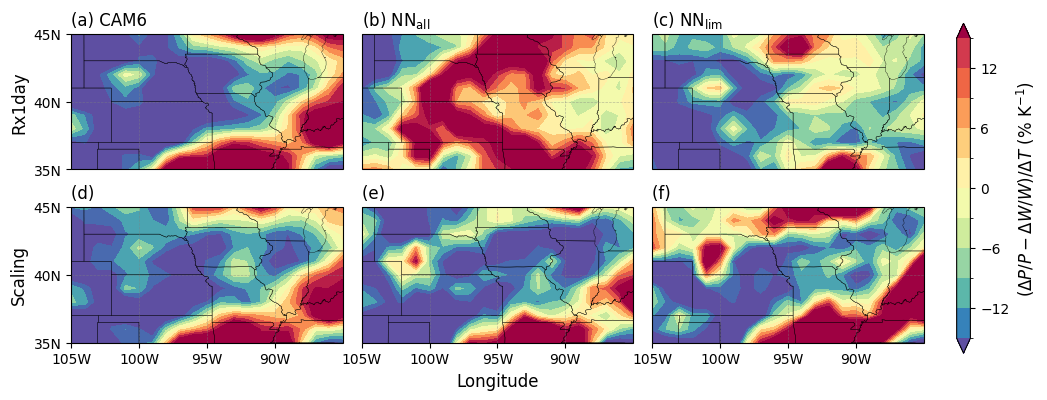

In [153]:
## technically should probably redo scaling calculations for the filtered data right?
## then use that since that is what we are comparing everywhere else?
daily_scaling = [
    xr.open_dataset('./CAM6_scaling.CTRL.nc'),
    xr.open_dataset('./DL_all_scaling.CTRL.nc'),
    xr.open_dataset('./DL_noqw_scaling.CTRL.nc'),
    xr.open_dataset('./CAM6_scaling.2K.nc'),
    xr.open_dataset('./DL_all_scaling.2K.nc'),
    xr.open_dataset('./DL_noqw_scaling.2K.nc'),
]
LABELS = [
    'CAM6 CTRL',
    NN_all_label + ' CTRL',
    NN_lim_label + ' CTRL',
    'CAM6 4K',
    NN_all_label + ' 4K',
    NN_lim_label + ' 4K'
]
daily_scaling = [da.assign_attrs(label=l) for da, l in zip(daily_scaling, LABELS)]

fig = plot_frac_change(daily_scaling[:3], daily_scaling[3:])
show(fig)
# plt.savefig('./CC_change.pdf', bbox_inches='tight', format='pdf', pad_inches=0.02)

In [186]:
fig = plot_scaling(daily_scaling[:3], maxP=80)
# show(fig)
plt.savefig('./ctrl_scaling.pdf', format='pdf', bbox_inches='tight', pad_inches=0.02)

In [187]:
fig = plot_scaling(daily_scaling[3:], maxP=80)
# show(fig)
plt.savefig('./4k_scaling.pdf', bbox_inches='tight', format='pdf', pad_inches=0.02)